# Seasonal Agriculture Performance Analysis

## Major Data Analytics Project

**Domain:** Agriculture  
**Project Theme:** Seasonal Agriculture Performance  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

### Project Goal

Investigate how agricultural performance varies across seasons and identify meaningful patterns, trends, relationships and differences in the available data.

> **Important:** This is a Data Analytics project. No Machine Learning or dashboard development is required.

# 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and economic conditions. As a result, agricultural performance may differ from one season to another.

The objective of this project is to analyze the given agricultural dataset and investigate seasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

Students should independently explore the dataset, formulate relevant analytical questions, select suitable analytical techniques and communicate findings based on evidence from the data.

# 2. Project Objectives

- Understand the structure and quality of the agricultural dataset.
- Clean and prepare the data for analysis.
- Explore seasonal patterns in the dataset.
- Perform descriptive and statistical analysis.
- Investigate relationships among relevant variables.
- Compare agricultural performance across seasons and other meaningful groups.
- Use appropriate univariate, bivariate and multivariate visualizations.
- Identify significant findings from the data.

# 3. Dataset

The dataset contains farm-level agricultural records covering different seasons, locations, crops, environmental conditions, farming practices, production, costs, revenue, profit and resource usage.

**Dataset file:** `seasonal_agriculture_performance_dataset.csv`

The notebook is designed so that students can upload/place the CSV in the same folder as this notebook.

In [3]:
# Import required libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the agriculture dataset
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

print("Dataset loaded successfully")

Dataset loaded successfully


# 4. Initial Data Understanding

In [5]:
# Dataset shape

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


In [6]:
# View the first five rows
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [7]:
#View the last 5 rows
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [8]:
# Column names
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [9]:
# Check the dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [10]:
# Statistical summary of numerical data
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


# 5. Data Quality Analysis

Before performing analysis, investigate missing values, duplicates, data types and unusual values.


In [11]:
# Check for missing values
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [12]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

In [13]:
# Fill missing values using the median

df["Rainfall_mm"] = df["Rainfall_mm"].fillna(df["Rainfall_mm"].median())
df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(df["Soil_Moisture_pct"].median())
df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(df["Yield_Tonnes_Ha"].median())

In [14]:
# Check for missing values
df.isnull().sum().sum()

np.int64(0)

In [15]:
# Check for outliers

for col in ["Yield_Tonnes_Ha", "Profit_INR", "Production_Tonnes"]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]

    print(col, ":", len(outliers), "outliers")

Yield_Tonnes_Ha : 302 outliers
Profit_INR : 404 outliers
Production_Tonnes : 333 outliers


# 6. Feature / Variable Review
The variables are reviewed conceptually as:

- **Identifier variables:** Farm_ID
- **Categorical variables:** State, District, Crop, Season, Irrigation_Method
- **Environmental variables:** Rainfall, temperature, humidity, sunlight, soil pH and soil moisture
- **Operational variables:** Nutrient inputs, irrigation, fertilizer, pesticide and seed quality
- **Production / performance variables:** Yield, production, water efficiency and disease/pest risk
- **Economic variables:** Market price, total cost, revenue and profit

The most relevant variables are **Season, Yield, Production, Profit, Revenue, Irrigation Method, Water Usage and environmental measures**, because they directly support the seasonal-performance problem.

In [16]:
# Separate numerical and categorical columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include='object').columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [17]:
# Check the number of records in each season
df['Season'].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [18]:
# Check the number of records for each crop
df['Crop'].value_counts()

,count
Crop,
Rice,690
Wheat,614
Maize,551
Cotton,508
Pulses,496
Groundnut,424
Chilli,412
Sugarcane,305


In [19]:
df['Irrigation_Method'].value_counts()

,count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


In [20]:
df['State'].value_counts()

,count
State,
Andhra Pradesh,529
Telangana,516
Maharashtra,512
Madhya Pradesh,497
Karnataka,489
Gujarat,488
Tamil Nadu,485
Punjab,484


# 7. Statistical Analysis

Descriptive statistics are used to understand the distribution, central tendency and variation of the numerical variables.

In [21]:
# Descriptive statistics

stats = df[numeric_columns].describe().T
stats["range"] = stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]

stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00,14.500,7.39000
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20,1315.200,460.40000
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70,23.500,5.70000
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00,70.000,17.12500
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00,7.500,1.50000
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40,3.200,0.88000
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00,39.000,9.40000
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00,180.000,42.72500
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00,105.000,23.20000
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00,170.000,37.40000


In [22]:
# Mean, median and standard deviation

statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std_Dev": df[numeric_columns].std(),
    "Min": df[numeric_columns].min(),
    "Max": df[numeric_columns].max()
})

statistical_summary

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.888265,7.8950,4.223764,0.500,15.00
Rainfall_mm,600.922825,582.0000,287.193381,80.000,1395.20
Avg_Temperature_C,26.818900,26.9000,3.818180,16.200,39.70
Humidity_pct,63.210500,63.0000,11.960834,25.000,95.00
Sunlight_Hours_Day,7.323050,7.3000,1.121186,3.500,11.00
Soil_pH,6.701010,6.6900,0.641461,5.200,8.40
Soil_Moisture_pct,26.507150,26.4000,6.678837,8.000,47.00
Nitrogen_kg_ha,120.250825,120.1000,31.216452,40.000,220.00
Phosphorus_kg_ha,57.781850,57.5000,17.015074,15.000,120.00
Potassium_kg_ha,104.760050,105.1000,27.742681,30.000,200.00


In [23]:
# Compare numerical variables across seasons

season_summary = df.groupby('Season')[numeric_columns].agg(['mean', 'median', 'std'])

season_summary.round(2)

Farm_Area_Hectares              Rainfall_mm                 \
                     mean median   std        mean median     std   
Season                                                              
Kharif               7.94   8.18  4.28      849.20  853.1  183.69   
Rabi                 7.75   7.68  4.18      437.62  432.2  175.35   
Zaid                 8.09   8.09  4.16      304.65  288.2  157.24   

       Avg_Temperature_C              Humidity_pct  ... Profit_INR  \
                    mean median   std         mean  ...        std   
Season                                              ...              
Kharif             28.45   28.5  2.51        71.81  ...  611549.78   
Rabi               23.49   23.5  2.46        57.89  ...  489901.25   
Zaid               31.04   31.0  2.55        52.01  ...  436356.75   

       Water_Used_m3                  Water_Efficiency_t_per_1000m3         \
                mean  median      std                          mean median   
Season                                                                       
Kharif       6102.20  4469.0  5670.58                          5.89   3.28   
Rabi         5846.99  4292.0  5397.65                          5.19   2.74   
Zaid         6419.89  4805.0  5734.62                          4.41   2.30   

             Disease_Pest_Risk_pct                
         std                  mean median    std  
Season                                            
Kharif  9.83                 54.47   54.5  10.09  
Rabi    8.26                 40.48   40.6  10.10  
Zaid    6.93                 38.22   37.9   9.87  

[3 rows x 66 columns]

# 8. Univariate Analysis

Univariate analysis examines one variable at a time to understand frequency and distribution patterns.

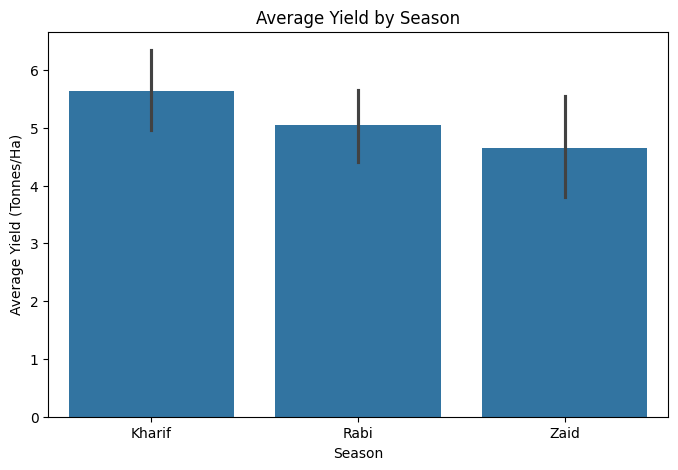

In [64]:
# Average yield by season

plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Season', y='Yield_Tonnes_Ha')
plt.title('Average Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.show()

In [65]:
# Average yield by crop

df.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

,Yield_Tonnes_Ha
Crop,
Sugarcane,46.642361
Maize,2.710036
Rice,2.431304
Wheat,2.108013
Chilli,1.542767
Groundnut,1.322901
Cotton,1.229783
Pulses,0.921512


In [66]:
# Average yield by irrigation method

df.groupby('Irrigation_Method')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

,Yield_Tonnes_Ha
Irrigation_Method,
Drip,6.577989
Sprinkler,5.160627
Flood,4.863977
Rainfed,4.602142


In [67]:
# Average profit by irrigation method

df.groupby('Irrigation_Method')['Profit_INR'].mean().sort_values(ascending=False)

,Profit_INR
Irrigation_Method,
Drip,219625.997814
Sprinkler,91121.079019
Rainfed,79050.365034
Flood,73354.022901


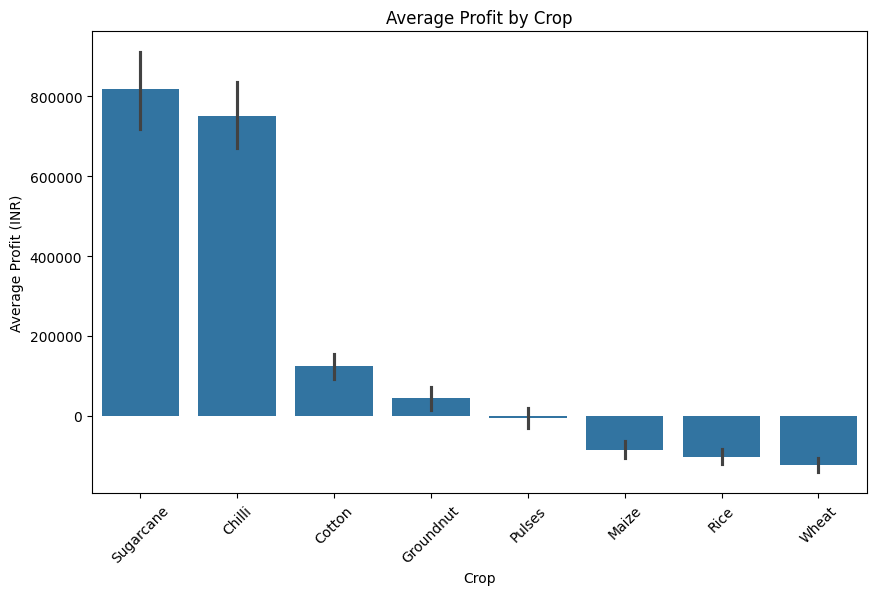

In [71]:
# Average profit by crop

plt.figure(figsize=(10,6))
sns.barplot(
    data=df,
    x='Crop',
    y='Profit_INR',
    estimator='mean',
    order=df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False).index
)
plt.title('Average Profit by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)
plt.show()

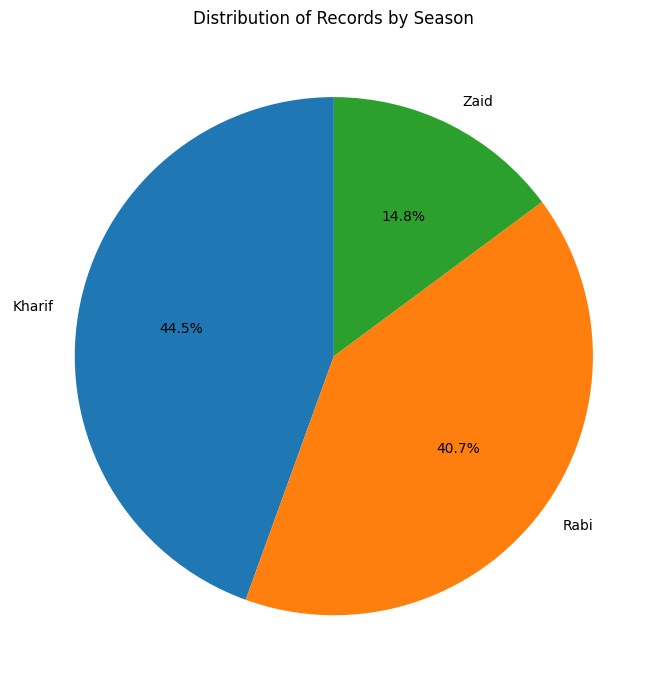

In [68]:
# Univariate: Season distribution (Pie Chart)

plt.figure(figsize=(7, 7))
df['Season'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribution of Records by Season')
plt.ylabel('')
plt.tight_layout()
plt.show()

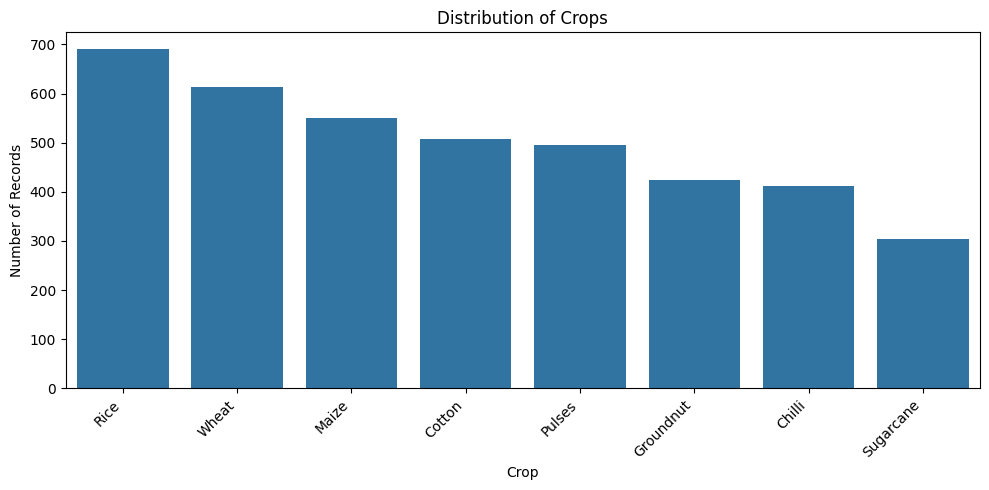

In [25]:
# Univariate: Crop distribution

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Crop', order=df['Crop'].value_counts().index)
plt.xticks(rotation=45, ha='right')
plt.title('Distribution of Crops')
plt.xlabel('Crop')
plt.ylabel('Number of Records')
plt.tight_layout()
plt.show()

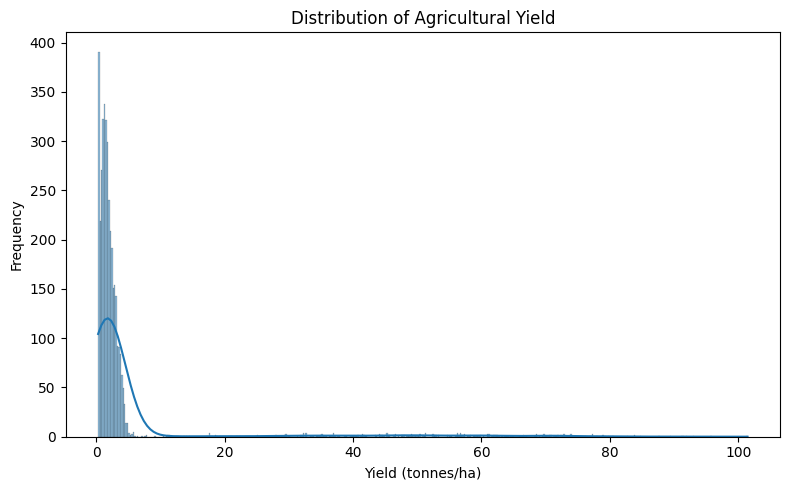

In [26]:
# Univariate: Yield distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Yield_Tonnes_Ha', kde=True)
plt.title('Distribution of Agricultural Yield')
plt.xlabel('Yield (tonnes/ha)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

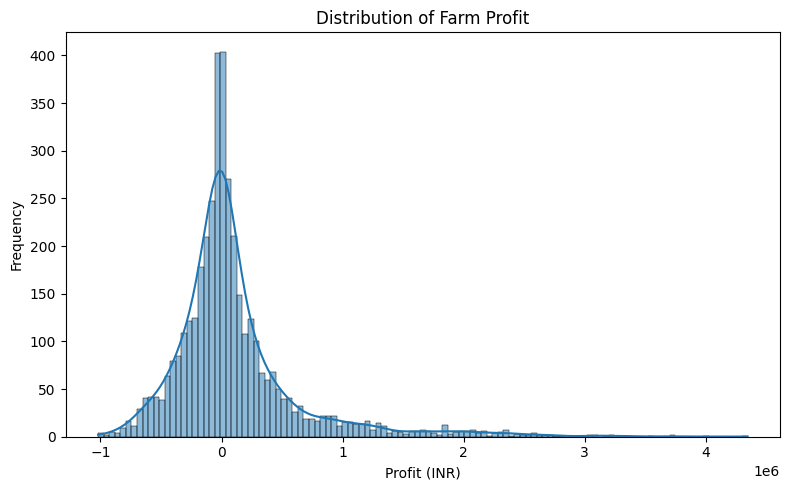

In [27]:
# Univariate: Profit distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Profit_INR', kde=True)
plt.title('Distribution of Farm Profit')
plt.xlabel('Profit (INR)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

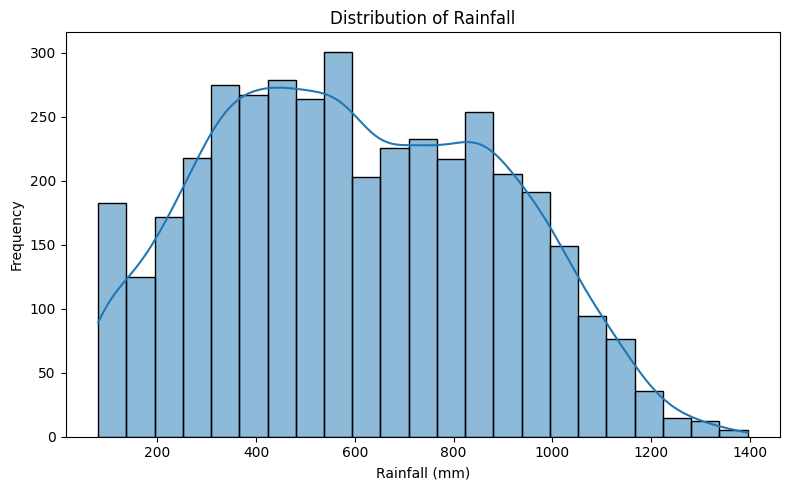

In [28]:
# Univariate: Rainfall distribution

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Rainfall_mm', kde=True)
plt.title('Distribution of Rainfall')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

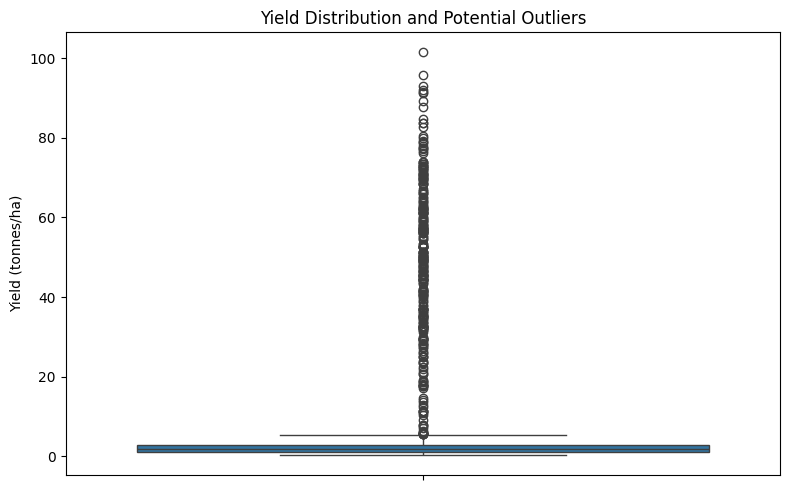

In [29]:
# Univariate: Yield boxplot

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, y='Yield_Tonnes_Ha')
plt.title('Yield Distribution and Potential Outliers')
plt.ylabel('Yield (tonnes/ha)')
plt.tight_layout()
plt.show()

# 9. Outlier Analysis

Investigate potential outliers using statistical and visual methods.



In [30]:
# IQR-based outlier summary
outlier_summary = []

for col in numeric_columns:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_summary.append({
        'Column': col,
        'Lower_Bound': round(lower, 2),
        'Upper_Bound': round(upper, 2),
        'Outlier_Count': int(count),
        'Outlier_Percentage': round(count / len(df) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)
outlier_summary.sort_values('Outlier_Count', ascending=False).head(10)

,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,-696111.00,763567.00,404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.62,5.50,302,7.55
19,Water_Used_m3,-6072.75,16171.25,276,6.90
17,Revenue_INR,-736519.00,1780911.00,240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


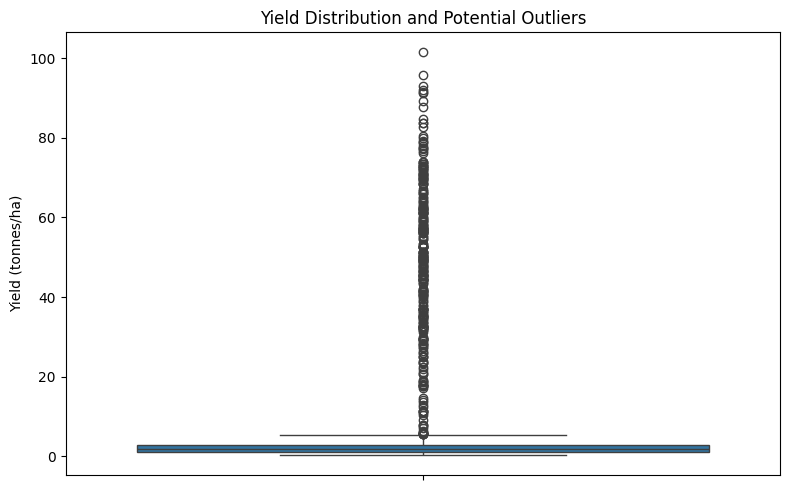

In [31]:
# Create a visualization for the analysis
plt.figure(figsize=(8,5))
sns.boxplot(data=df, y='Yield_Tonnes_Ha')
plt.title('Yield Distribution and Potential Outliers')
plt.ylabel('Yield (tonnes/ha)')
plt.tight_layout()
plt.show()

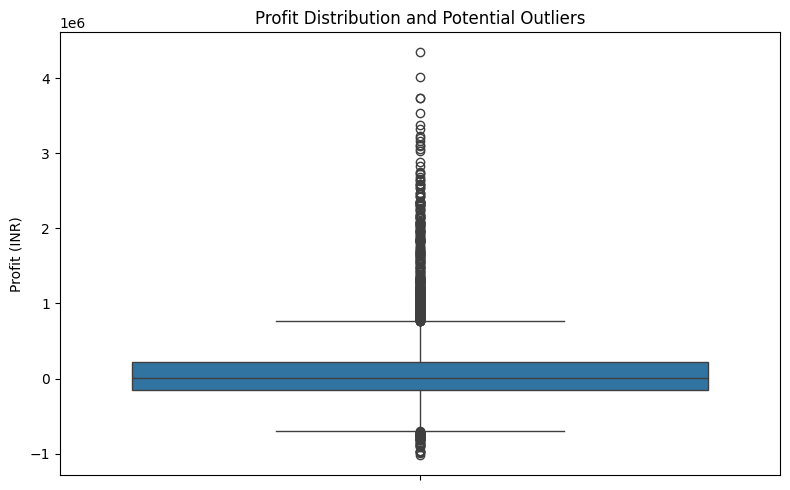

In [32]:
# Create a visualization for the analysis
plt.figure(figsize=(8,5))
sns.boxplot(data=df, y='Profit_INR')
plt.title('Profit Distribution and Potential Outliers')
plt.ylabel('Profit (INR)')
plt.tight_layout()
plt.show()

# 10. Bivariate Analysis

Bivariate analysis is used to study the relationship between two variables.

The analysis focuses on relationships that are relevant to seasonal agricultural performance.

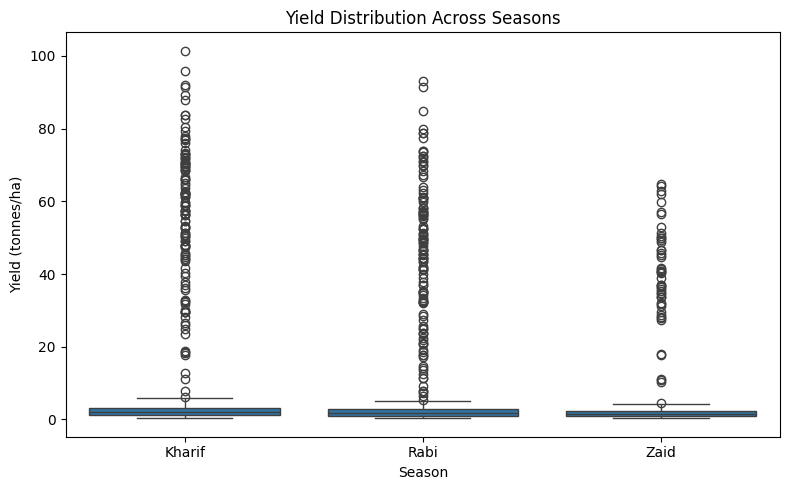

In [33]:
# Create a visualization for the analysis
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Season', y='Yield_Tonnes_Ha')
plt.title('Yield Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Yield (tonnes/ha)')
plt.tight_layout()
plt.show()

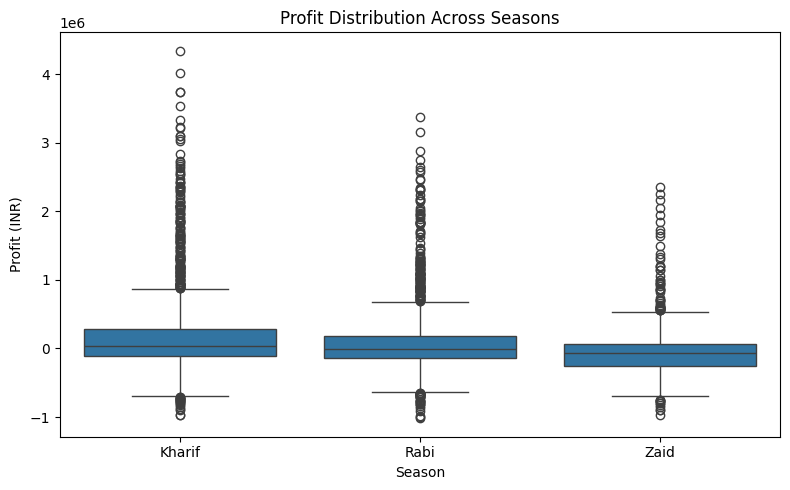

In [34]:
# Create a visualization for the analysis
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Season', y='Profit_INR')
plt.title('Profit Distribution Across Seasons')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')
plt.tight_layout()
plt.show()

In [35]:
# Calculate correlations between numerical variables
df[['Rainfall_mm', 'Yield_Tonnes_Ha']].corr()

,Rainfall_mm,Yield_Tonnes_Ha
Rainfall_mm,1.000000,0.030951
Yield_Tonnes_Ha,0.030951,1.000000


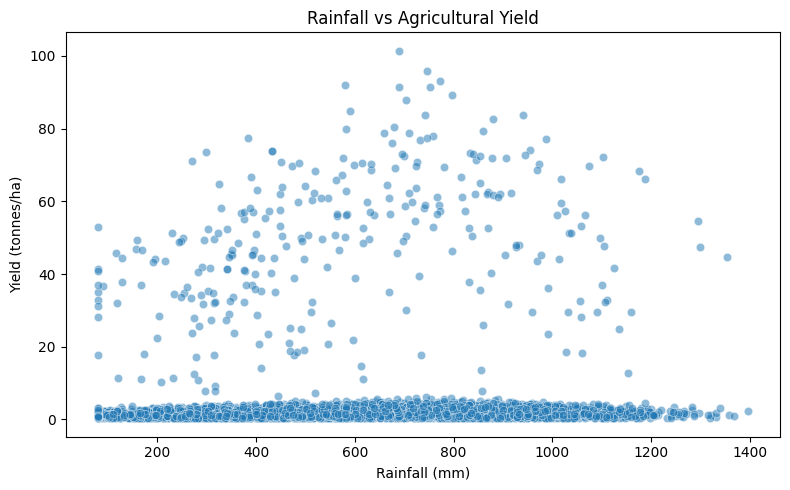

In [69]:
# Rainfall vs agricultural yield

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Rainfall_mm', y='Yield_Tonnes_Ha', alpha=0.5)
plt.title('Rainfall vs Agricultural Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (tonnes/ha)')
plt.tight_layout()
plt.show()

In [36]:
# Calculate correlations between numerical variables
df[['Farm_Area_Hectares', 'Yield_Tonnes_Ha']].corr()

,Farm_Area_Hectares,Yield_Tonnes_Ha
Farm_Area_Hectares,1.000000,0.030203
Yield_Tonnes_Ha,0.030203,1.000000


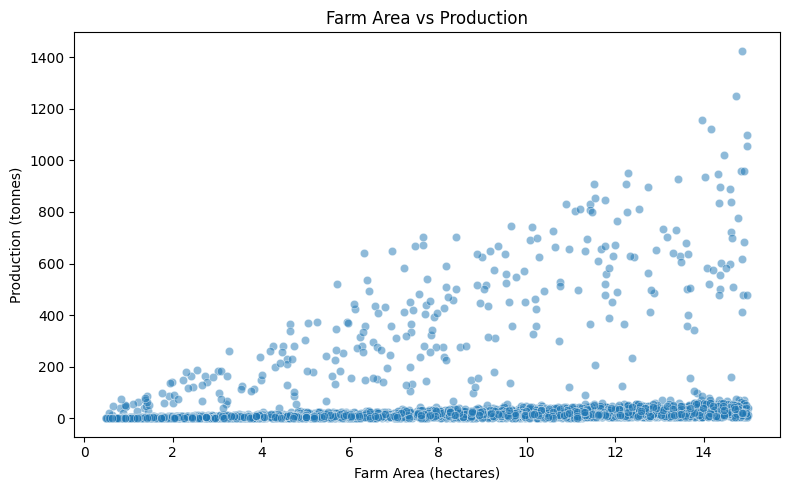

In [70]:
# Farm area vs production

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Farm_Area_Hectares', y='Production_Tonnes', alpha=0.5)
plt.title('Farm Area vs Production')
plt.xlabel('Farm Area (hectares)')
plt.ylabel('Production (tonnes)')
plt.tight_layout()
plt.show()

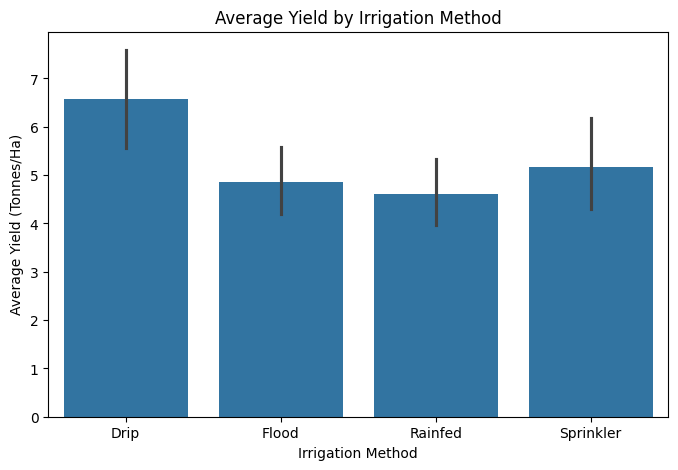

In [37]:
# Create a visualization for the analysis
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Irrigation_Method', y='Yield_Tonnes_Ha')
plt.title('Average Yield by Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.show()

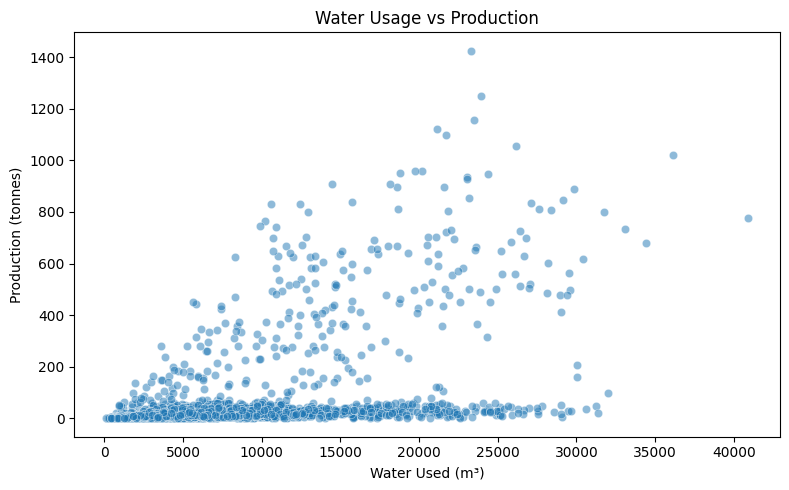

In [38]:
# Water usage vs production
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Water_Used_m3', y='Production_Tonnes', alpha=0.5)
plt.title('Water Usage vs Production')
plt.xlabel('Water Used (m³)')
plt.ylabel('Production (tonnes)')
plt.tight_layout()
plt.show()

# 11. Multivariate Analysis

Multivariate analysis examines several variables together to understand how season interacts with crop, irrigation, environmental conditions and economic performance.

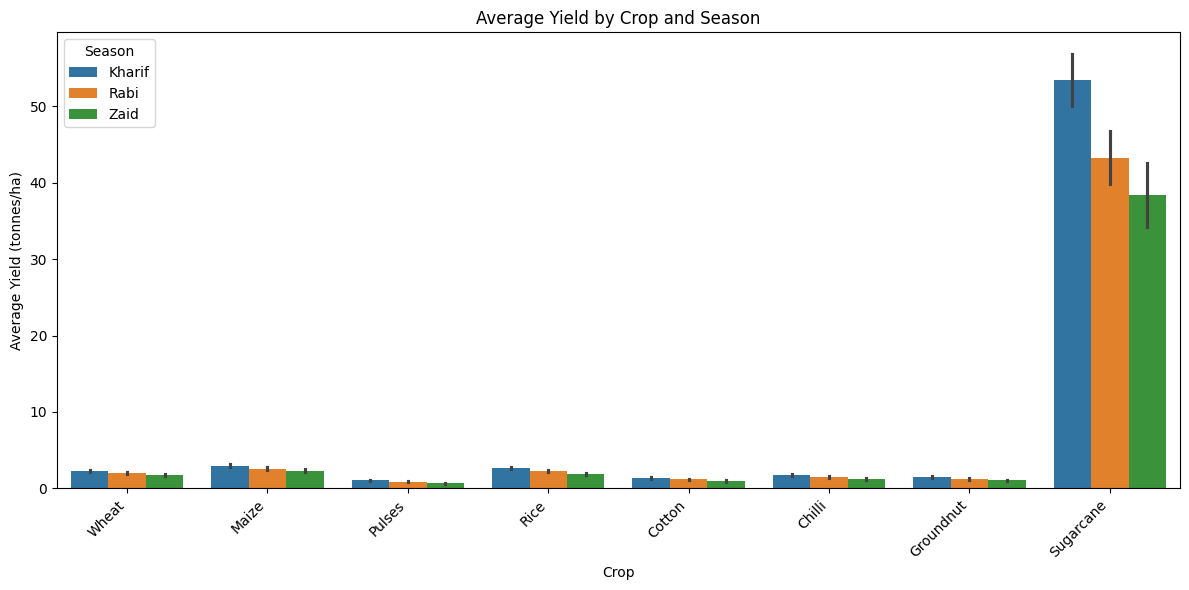

In [39]:
# Create a visualization for the analysis
plt.figure(figsize=(12,6))
sns.barplot(data=df, x='Crop', y='Yield_Tonnes_Ha', hue='Season')
plt.xticks(rotation=45, ha='right')
plt.title('Average Yield by Crop and Season')
plt.xlabel('Crop')
plt.ylabel('Average Yield (tonnes/ha)')
plt.tight_layout()
plt.show()

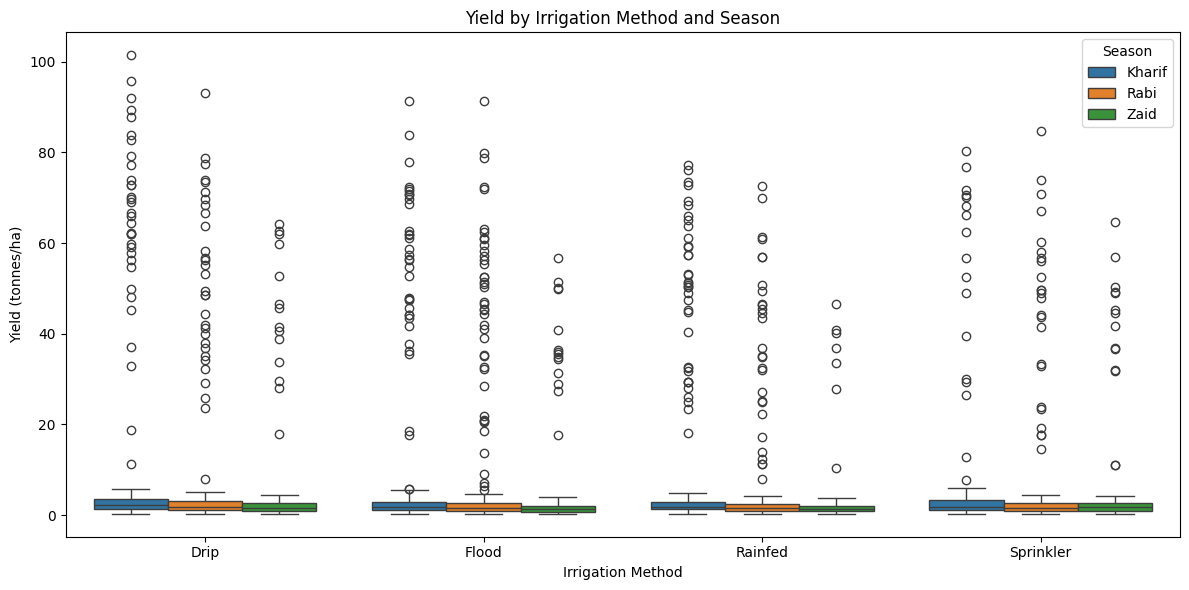

In [40]:
# Create a visualization for the analysis
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Irrigation_Method', y='Yield_Tonnes_Ha', hue='Season')
plt.title('Yield by Irrigation Method and Season')
plt.xlabel('Irrigation Method')
plt.ylabel('Yield (tonnes/ha)')
plt.tight_layout()
plt.show()

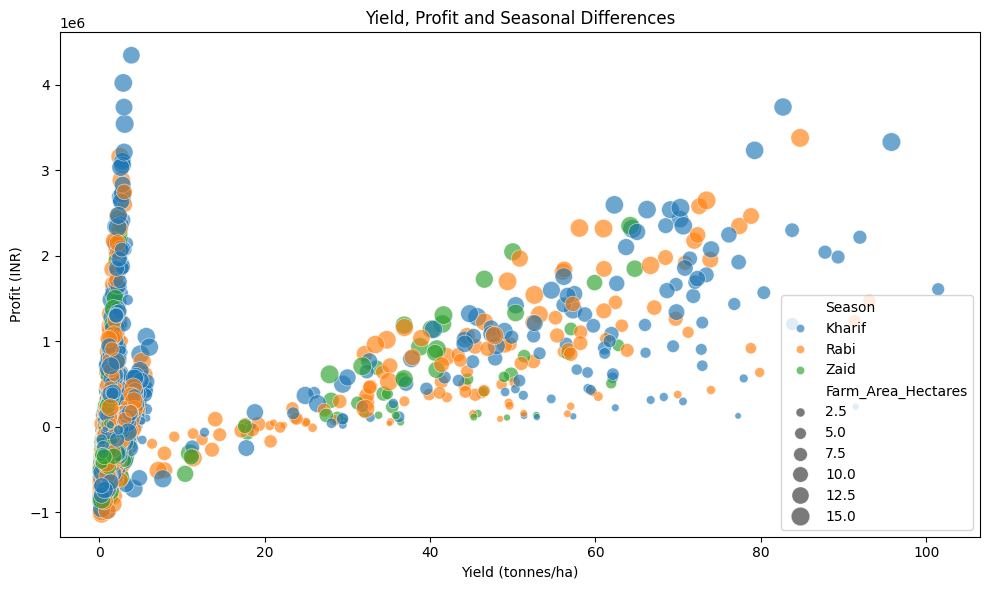

In [41]:
# Create a visualization for the analysis
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Yield_Tonnes_Ha',
    y='Profit_INR',
    hue='Season',
    size='Farm_Area_Hectares',
    sizes=(20, 180),
    alpha=0.65
)
plt.title('Yield, Profit and Seasonal Differences')
plt.xlabel('Yield (tonnes/ha)')
plt.ylabel('Profit (INR)')
plt.tight_layout()
plt.show()

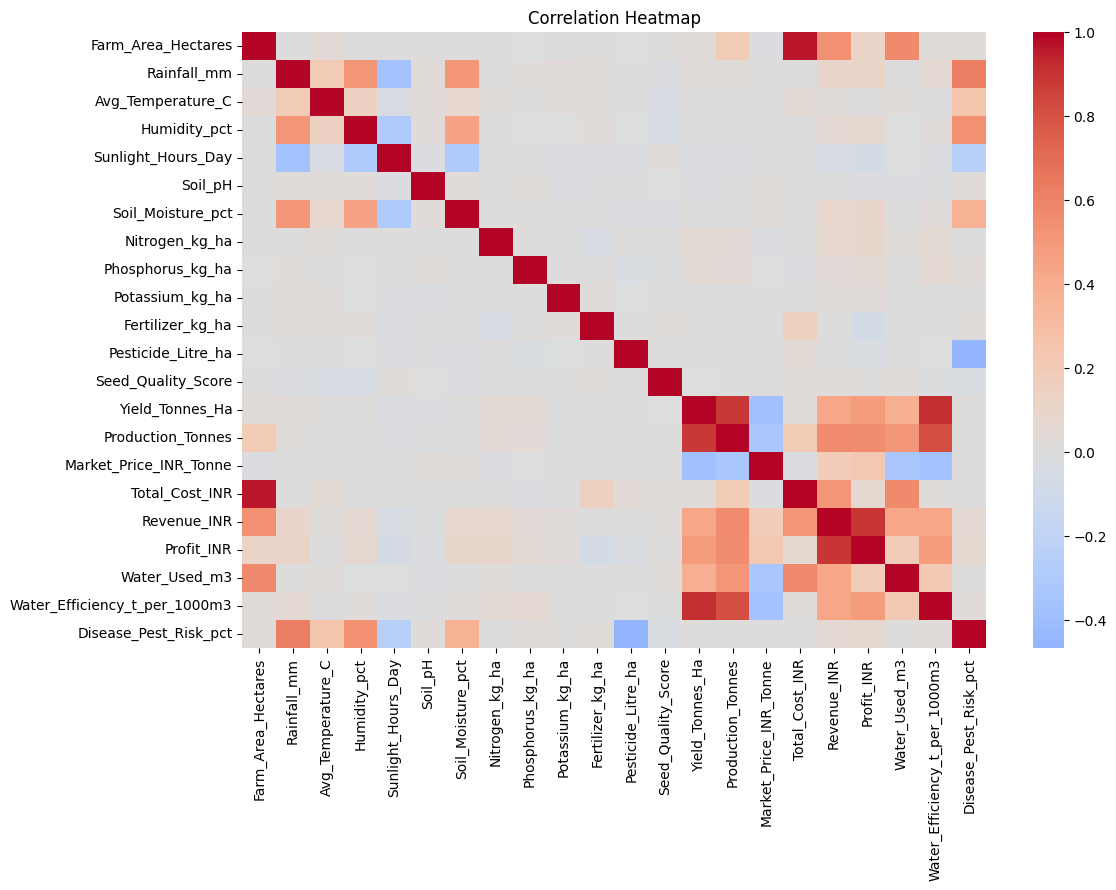

In [42]:
# Create a visualization for the analysis
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

# 12. Seasonal Comparison
The seasons are compared using meaningful measures such as yield, production, profit, water usage and water efficiency.

In [43]:
# Summarize the data by the selected groups
season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).round(2)

season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used,Average_Water_Efficiency
Season,,,,,,,
Kharif,1779,5.63,82387.61,178914.65,318289158,6102.20,5.89
Rabi,1627,5.04,67498.88,87689.47,142670768,5846.99,5.19
Zaid,594,4.64,23098.35,-24804.82,-14734066,6419.89,4.41


In [44]:
# Summarize the data by the selected groups
crop_season_summary = df.groupby(["Season", "Crop"]).agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).round(2)

crop_season_summary

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Chilli              1.73       954380.42                      3.26
       Cotton              1.37       216999.55                      2.13
       Groundnut           1.48       108265.44                      3.58
       Maize               2.97       -39332.67                      6.05
       Pulses              1.04        43338.90                      3.35
       Rice                2.70       -64903.40                      2.17
       Sugarcane          53.46      1000790.81                     36.00
       Wheat               2.25      -105871.87                      4.76
Rabi   Chilli              1.47       638572.50                      2.89
       Cotton              1.20       107343.59                      1.94
       Groundnut           1.23        10416.54                      2.90
       Maize               2.60       -89133.40                      5.46
       Pulses              0.88       -14309.14                      2.70
       Rice                2.32       -98427.87                      1.84
       Sugarcane          43.29       731612.86                     27.92
       Wheat               2.06      -119954.57                      4.69
Zaid   Chilli              1.20       448659.09                      2.20
       Cotton              0.96       -53925.34                      1.49
       Groundnut           1.04       -68872.50                      2.47
       Maize               2.29      -194049.17                      4.75
       Pulses              0.67      -139227.81                      1.95
       Rice                1.90      -227239.34                      1.53
       Sugarcane          38.42       583635.80                     23.39
       Wheat               1.75      -193208.95                      4.02

In [45]:
# Perform statistical testing for group differences
from scipy.stats import f_oneway

kharif = df[df['Season'] == 'Kharif']['Yield_Tonnes_Ha']
rabi = df[df['Season'] == 'Rabi']['Yield_Tonnes_Ha']
zaid = df[df['Season'] == 'Zaid']['Yield_Tonnes_Ha']

f_stat, p_value = f_oneway(kharif, rabi, zaid)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 1.5438804542488311
P-value: 0.21367813841792296


In [46]:
# Perform statistical testing for group differences
drip = df[df['Irrigation_Method'] == 'Drip']['Yield_Tonnes_Ha']
sprinkler = df[df['Irrigation_Method'] == 'Sprinkler']['Yield_Tonnes_Ha']
flood = df[df['Irrigation_Method'] == 'Flood']['Yield_Tonnes_Ha']
rainfed = df[df['Irrigation_Method'] == 'Rainfed']['Yield_Tonnes_Ha']

f_stat, p_value = f_oneway(drip, sprinkler, flood, rainfed)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 4.24554845996922
P-value: 0.005287932851309753


In [47]:
# Summarize the data by the selected groups
df.groupby('Season')['Yield_Tonnes_Ha'].mean()

,Yield_Tonnes_Ha
Season,
Kharif,5.628612
Rabi,5.039435
Zaid,4.641313


In [48]:
# Summarize the data by the selected groups
df.groupby('Season')['Production_Tonnes'].mean()

,Production_Tonnes
Season,
Kharif,46.311192
Rabi,41.486712
Zaid,38.886111


In [49]:
# Summarize the data by the selected groups
df.groupby('Season')['Profit_INR'].mean()

,Profit_INR
Season,
Kharif,178914.647555
Rabi,87689.470191
Zaid,-24804.824916


In [50]:
# Summarize the data by the selected groups
df.groupby('Season')['Revenue_INR'].mean()

,Revenue_INR
Season,
Kharif,710719.055649
Rabi,601526.048556
Zaid,519171.904040


In [51]:
# Summarize the data by the selected groups
df.groupby('Season')['Total_Cost_INR'].mean()

,Total_Cost_INR
Season,
Kharif,531804.408094
Rabi,513836.578365
Zaid,543976.728956


In [52]:
# Summarize the data by the selected groups
df.groupby('Season')[['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Soil_Moisture_pct']].mean()

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct
Season,,,,
Kharif,849.199663,28.454019,71.812591,31.149859
Rabi,437.615366,23.489183,57.893178,24.069392
Zaid,304.654714,31.042088,52.012121,19.279630


In [53]:
# Summarize the data by the selected groups
df.groupby('Irrigation_Method')['Water_Used_m3'].mean().sort_values(ascending=False)

,Water_Used_m3
Irrigation_Method,
Flood,8026.472519
Sprinkler,6208.258856
Drip,5918.747541
Rainfed,3549.554275


In [54]:
# Summarize the data by the selected groups
df.groupby(['Season', 'Irrigation_Method'])['Profit_INR'].mean().unstack()

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,317222.071605,133373.832203,158974.125270,116880.492212
Rabi,187843.221622,58824.798479,45232.479452,76502.068259
Zaid,21291.835714,-69786.778351,-79467.257143,57909.400000


In [55]:
# Summarize the data by the selected groups
df.groupby(['Season', 'Irrigation_Method']).size().unstack()

Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


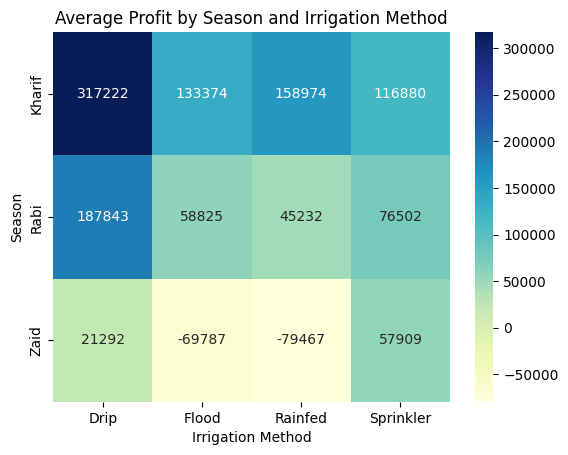

In [56]:
# Create a visualization for the analysis
profit_pivot = df.groupby(['Season', 'Irrigation_Method'])['Profit_INR'].mean().unstack()

sns.heatmap(profit_pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Average Profit by Season and Irrigation Method')
plt.xlabel('Irrigation Method')
plt.ylabel('Season')
plt.show()

# 13. Additional Student-Driven Analysis
Three additional analyses were selected to add state-level, crop-level and resource-use perspectives.

### Analysis 1: State-wise Profitability

**Question:** Which states have higher average farm profit?

In [57]:
# Summarize the data by the selected groups
df.groupby('State')['Profit_INR'].mean().sort_values(ascending=False)

,Profit_INR
State,
Punjab,136025.636364
Maharashtra,135428.855469
Karnataka,119422.335378
Tamil Nadu,117744.748454
Gujarat,117568.235656
Telangana,108829.616279
Madhya Pradesh,86840.756539
Andhra Pradesh,73453.527410


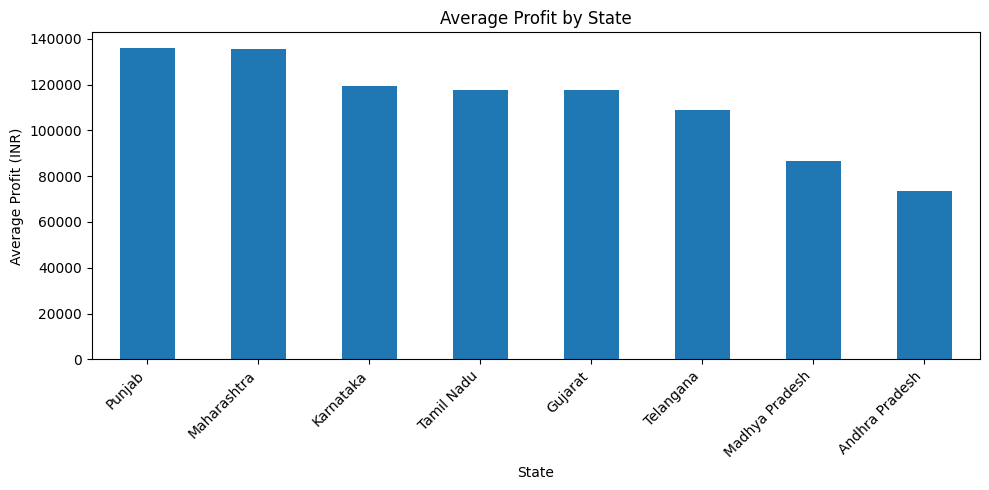

In [58]:
# Create a visualization for the analysis
state_profit = df.groupby('State')['Profit_INR'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
state_profit.plot(kind='bar')
plt.title('Average Profit by State')
plt.xlabel('State')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Analysis 2: Crop-wise Revenue

**Question:** Which crops generate higher average revenue?

In [59]:
# Summarize the data by the selected groups
df.groupby('Crop')['Revenue_INR'].mean().sort_values(ascending=False)

,Revenue_INR
Crop,
Sugarcane,1.371980e+06
Chilli,1.276777e+06
Cotton,6.394231e+05
Groundnut,5.429355e+05
Pulses,5.284659e+05
Maize,4.570680e+05
Rice,4.236153e+05
Wheat,4.001049e+05


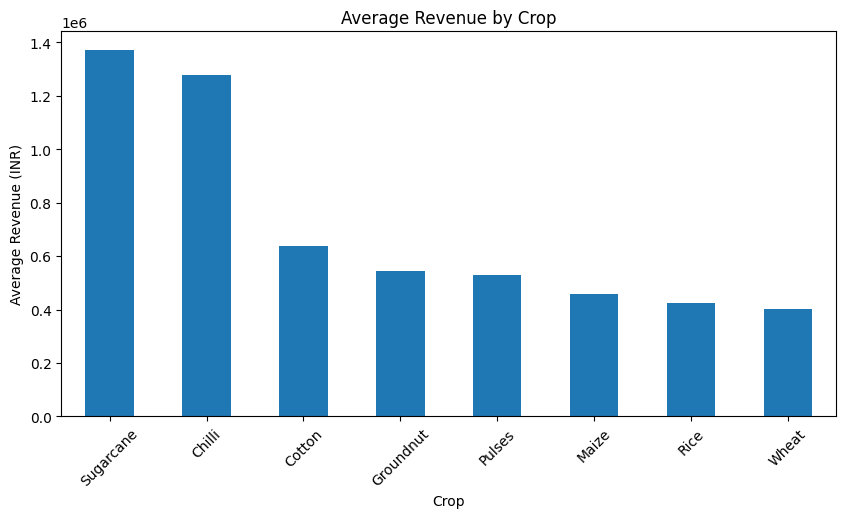

In [60]:
# Create a visualization for the analysis
crop_revenue = df.groupby('Crop')['Revenue_INR'].mean().sort_values(ascending=False)

crop_revenue.plot(kind='bar', figsize=(10, 5), title='Average Revenue by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Revenue (INR)')
plt.xticks(rotation=45)
plt.show()

### Analysis 3: State–Crop Profitability

**Question:** Which state and crop combinations generate higher average profit?

In [72]:
# Summarize the data by the selected groups
df.groupby(['State', 'Crop'])['Profit_INR'].mean().sort_values(ascending=False).head(10)

,,Profit_INR
State,Crop,
Tamil Nadu,Sugarcane,979775.387097
Maharashtra,Chilli,929988.150943
Gujarat,Chilli,901790.217391
Maharashtra,Sugarcane,893729.305556
Andhra Pradesh,Sugarcane,867348.935484
Gujarat,Sugarcane,852212.476190
Madhya Pradesh,Sugarcane,796706.828571
Karnataka,Chilli,760005.480769
Tamil Nadu,Chilli,747757.909091


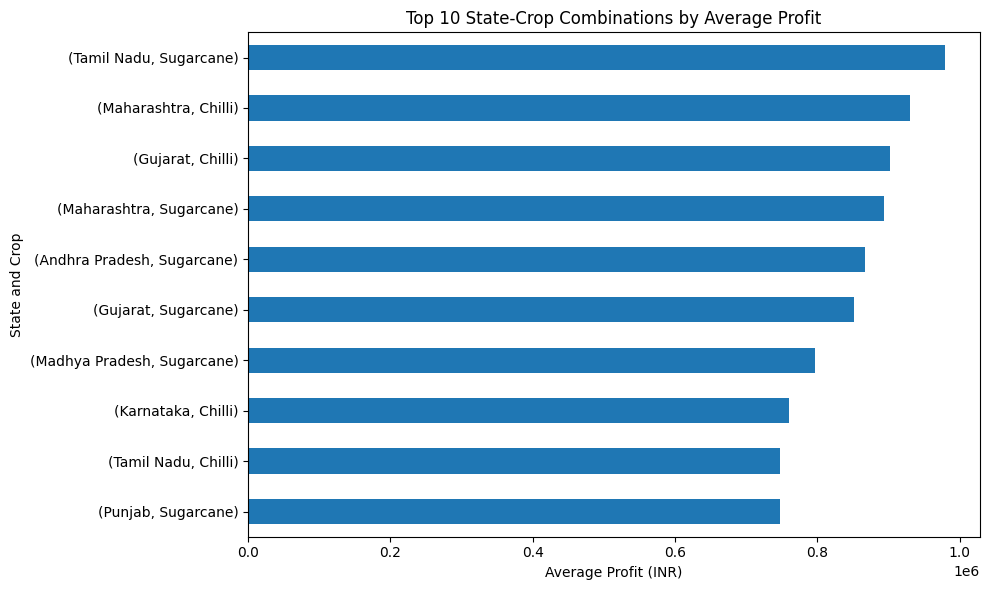

In [73]:
# Select the top 10 state-crop combinations
state_crop_profit = df.groupby(['State', 'Crop'])['Profit_INR'].mean().sort_values(ascending=False).head(10)

# Create a bar chart
state_crop_profit.sort_values().plot(kind='barh', figsize=(10, 6))

plt.title('Top 10 State-Crop Combinations by Average Profit')
plt.xlabel('Average Profit (INR)')
plt.ylabel('State and Crop')
plt.tight_layout()
plt.show()

In [63]:
# Summarize the data by the selected groups
profit_combo = df.groupby(['Season', 'Irrigation_Method'])['Profit_INR'].mean().sort_values(ascending=False)

profit_combo.head(5)

Season  Irrigation_Method
Kharif  Drip                 317222.071605
Rabi    Drip                 187843.221622
Kharif  Rainfed              158974.125270
        Flood                133373.832203
        Sprinkler            116880.492212
Name: Profit_INR, dtype: float64

# 14. Key Insights
### Insight 1 — Kharif has the highest average yield
- **Observation:** Kharif records about **5.63 tonnes/ha**, the highest among the three seasons.
- **Evidence:** Seasonal yield comparison.
- **Interpretation:** Kharif shows the strongest average yield in this dataset.
- **Limitation:** The season ANOVA p-value is about **0.214**, so the difference is not statistically significant at the 5% level.

### Insight 2 — Kharif has the strongest average profit
- **Observation:** Kharif records about **₹178,915** average profit.
- **Evidence:** Seasonal profit comparison.
- **Interpretation:** Kharif is the strongest season economically in the dataset.
- **Limitation:** The result is an association and does not prove that season alone causes higher profit.

### Insight 3 — Zaid has negative average profit
- **Observation:** Zaid records about **-₹24,805** average profit.
- **Evidence:** Seasonal profit analysis.
- **Interpretation:** Zaid shows weaker average economic performance.
- **Limitation:** Crop mix, costs, prices and irrigation may also contribute to this result.

### Insight 4 — Drip irrigation has the highest average yield
- **Observation:** Drip irrigation records about **6.58 tonnes/ha** average yield.
- **Evidence:** Irrigation comparison and ANOVA.
- **Interpretation:** Irrigation method is an important dimension for yield comparison.
- **Limitation:** Statistical significance does not prove that irrigation alone causes the difference.

### Insight 5 — Sugarcane has the highest average profit
- **Observation:** Sugarcane records about **₹817,188** average profit.
- **Evidence:** Crop profitability analysis.
- **Interpretation:** Sugarcane is the strongest crop economically in this dataset.
- **Limitation:** Crop characteristics and the much higher production values should be considered when comparing crops.

### Insight 6 — Water usage has a moderate positive relationship with production
- **Observation:** The correlation is about **0.516**.
- **Evidence:** Water usage vs production analysis.
- **Interpretation:** Higher water usage tends to occur with higher production in this dataset.
- **Limitation:** Correlation does not establish causation.

### Insight 7 — Disease/pest risk has almost no linear relationship with yield
- **Observation:** The correlation with yield is about **0.014**.
- **Evidence:** Correlation analysis.
- **Interpretation:** Disease/pest risk alone does not show a meaningful linear association with yield here.
- **Limitation:** A near-zero correlation does not mean disease and pests have no agricultural impact.

### Insight 8 — Punjab has the highest average state profit
- **Observation:** Punjab records about **₹136,026** average profit.
- **Evidence:** State-wise profitability analysis.
- **Interpretation:** Punjab shows the highest average state-level profit in this dataset.
- **Limitation:** State averages can hide differences between individual crops, farms and seasons.

# 15. Recommendations
The recommendations are based only on the evidence in this dataset.

1. **Consider drip irrigation where feasible**, because it has the highest average yield and profit and irrigation groups show a statistically significant difference in yield.
2. **Give additional attention to Zaid-season planning**, because its average profit is negative in this dataset.
3. **Evaluate high-profit crops such as sugarcane and chilli** while also considering their resource requirements.
4. **Monitor water usage together with production**, because the dataset shows a moderate positive relationship between them.
5. **Use season, crop, state and irrigation together when planning**, rather than relying on one variable alone.
6. **Do not automatically remove outliers**; investigate whether extreme values represent genuine farm conditions.

# 16. Conclusion
The analysis shows meaningful differences in agricultural performance across seasons, crops, irrigation methods and states.

Kharif records the highest average yield and profit, while Zaid records negative average profit. Drip irrigation shows the highest average yield, and sugarcane records the highest average profit among crops. Water usage has a moderate positive relationship with production, while disease/pest risk has almost no linear relationship with yield.

Overall, the project demonstrates how data cleaning, descriptive statistics, visualization, correlation, outlier analysis and ANOVA can be combined to understand seasonal agricultural performance.

These findings are specific to the available dataset and should not be treated as universal agricultural rules.

# 17. Project Checklist
Before submission, confirm that the notebook includes:

- [x] Dataset loaded successfully
- [x] Top 5 rows analyzed
- [x] Dataset shape and structure examined
- [x] Data types examined
- [x] Missing values identified and handled
- [x] Duplicate records checked
- [x] Descriptive/statistical analysis performed
- [x] Outliers investigated
- [x] Univariate analysis completed
- [x] Bivariate analysis completed
- [x] Multivariate analysis completed
- [x] Seasonal comparison completed
- [x] 3 additional student-driven analyses completed
- [x] 8 evidence-based insights documented
- [x] Data-driven recommendations provided
- [x] Conclusion provided
- [x] Ready for GitHub submission